# Task 2: gRNA Design for CRISPRa

**Goal**: Systematically select the top downregulated genes on Chr 1 or 2, extract their first exons, and evaluate them in order until we find a robust guide RNA candidate that passes strict efficiency and specificity filters.

In [1]:
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gzip
import requests
import os
import glob

# Create directories if they don't exist
os.makedirs('../data', exist_ok=True)
os.makedirs('../results/tables', exist_ok=True)

## Systematic Gene Selection

Based on the project hypothesis, we want to use **CRISPRa (Activation)** to restore the expression of a gene that is significantly downregulated during SARS-CoV-2 infection.

To satisfy Task 3 constraints, the gene must also be on Chromosome 1 or 2. We will select the **Top 3** most severely downregulated genes to evaluate in order, in case our primary candidates fail biological constraints (e.g., exon too short, or highly repetitive).

Top 3 CRISPRa Candidates to evaluate:


,gene_name,chromosome,deseq_lfc
0,PASK,2,-3.888038
1,SLC16A1,1,-3.664508
2,PDPN,1,-3.543295


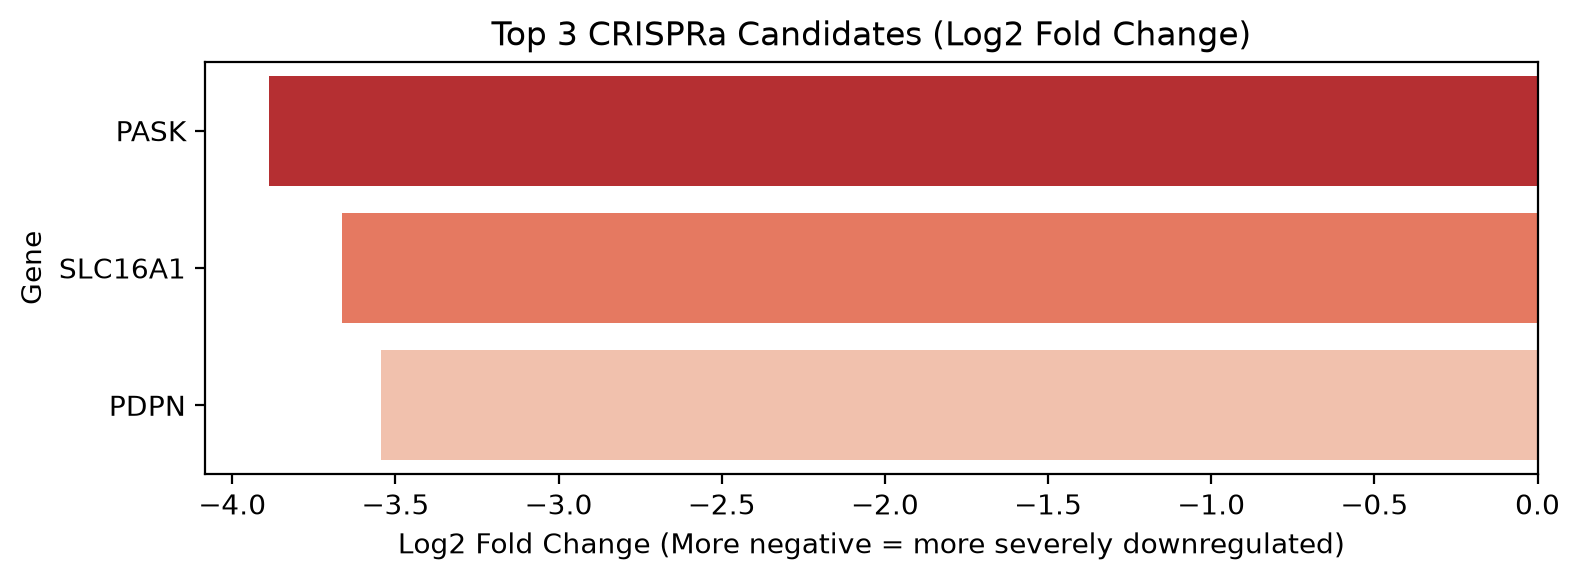

In [2]:
# Load the candidate genes from Task 1
candidates_df = pd.read_csv('../results/tables/target_candidates_chr1_chr2.csv')

# Filter for genes requiring CRISPRa (downregulated genes)
crispra_candidates = candidates_df[candidates_df['crispr_modality'] == 'CRISPRa (Activation)']

# Sort by the most severe downregulation (lowest Log2 Fold Change) and select Top 3
top_3_candidates = crispra_candidates.sort_values(by='deseq_lfc', ascending=True).head(3).reset_index(drop=True)

print("Top 3 CRISPRa Candidates to evaluate:")
display(top_3_candidates[['gene_name', 'chromosome', 'deseq_lfc']])

target_genes = top_3_candidates['gene_name'].tolist()
target_chroms = top_3_candidates['chromosome'].astype(str).tolist()
# Visualize the downregulation severity
plt.figure(figsize=(8, 3))
sns.barplot(data=top_3_candidates, x='deseq_lfc', y='gene_name', hue='gene_name', palette='Reds_r', legend=False)
plt.title('Top 3 CRISPRa Candidates (Log2 Fold Change)')
plt.xlabel('Log2 Fold Change (More negative = more severely downregulated)')
plt.ylabel('Gene')
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

## Parse GFF and Fetch Sequences

We will loop through our top 3 candidates, find their first exon in the GFF annotation, and dynamically fetch the DNA sequence from the `Ensembl REST API`.

In [3]:
gff_file = '../GCF_000001405.26_GRCh38_genomic.gff.gz'
chrom_map = {'1': 'NC_000001.11', '2': 'NC_000002.12'}

candidate_sequences = {}

for gene, chrom in zip(target_genes, target_chroms):
    target_seqid = chrom_map.get(chrom)
    target_exons = []
    
    # Parse GFF
    with gzip.open(gff_file, 'rt') as f:
        for line in f:
            if line.startswith('#'): continue
            if '\texon\t' in line and (f'={gene};' in line or f'={gene}' in line or f':{gene}' in line):
                parts = line.strip().split('\t')
                if parts[0] == target_seqid:
                    target_exons.append({'start': int(parts[3]), 'end': int(parts[4]), 'strand': parts[6]})
                    
    exons_df = pd.DataFrame(target_exons).drop_duplicates().reset_index(drop=True)
    
    if len(exons_df) == 0:
        print(f"[{gene}] Error: No exons found.")
        continue
        
    # Identify First Exon
    strand = exons_df['strand'].iloc[0]
    if strand == '-':
        first_exon = exons_df.sort_values(by='end', ascending=False).iloc[0]
    else:
        first_exon = exons_df.sort_values(by='start', ascending=True).iloc[0]

    # Fetch Sequence
    server = "https://rest.ensembl.org"
    ext = f"/sequence/region/human/{chrom}:{first_exon['start']}..{first_exon['end']}:{1 if strand == '+' else -1}"
    import time
    time.sleep(1)
    response = requests.get(server+ext, headers={ "Content-Type" : "text/plain"})
    
    if response.ok:
        seq = response.text
        candidate_sequences[gene] = seq
        print(f"[{gene}] First Exon Extracted. Length: {len(seq)} bp")
        
        # Save FASTA
        fasta_path = f"../data/{gene.lower()}_first_exon.fasta"
        with open(fasta_path, 'w') as f:
            f.write(f">{gene}_first_exon_chr{chrom}_{first_exon['start']}_{first_exon['end']}")
            f.write(seq)
    else:
        print(f"[{gene}] API Fetch Failed. HTTP {response.status_code}: {response.text}")
        import time
        time.sleep(1)

[PASK] First Exon Extracted. Length: 23 bp
[SLC16A1] First Exon Extracted. Length: 101 bp
[PDPN] First Exon Extracted. Length: 344 bp


## CRISPOR Execution

We now have FASTA files for our top candidates in the `data/` folder.
1. Go to [http://crispor.tefor.net/](http://crispor.tefor.net/)
2. Paste the sequence for each candidate.
3. Select Genome: **Human (GRCh38/hg38)** and PAM: **20bp-NGG (SpCas9)**.
4. Download the results for each as an Excel file (`.xls`), and name them `crispor_{gene}_results.xls` (e.g., `crispor_pask_results.xls`).
5. Place them in the `data/` folder.

*(Note: for "Found no possible guide sequence" result, simply ignore and move to the next instead of creating an empty xls file for it.)*

--- Evaluating Candidate: PASK ---
x Failed: No CRISPOR results file found for PASK.
 (This likely means the sequence was too short and lacked a PAM motif.)
--- Evaluating Candidate: SLC16A1 ---
x Failed: 0 guides passed the strict specificity filters for SLC16A1.
 (This likely means the exon sequence is highly repetitive, yielding massive off-targets.)
--- Evaluating Candidate: PDPN ---
o Success! PDPN yielded 10 high-quality guides passing all strict filters.


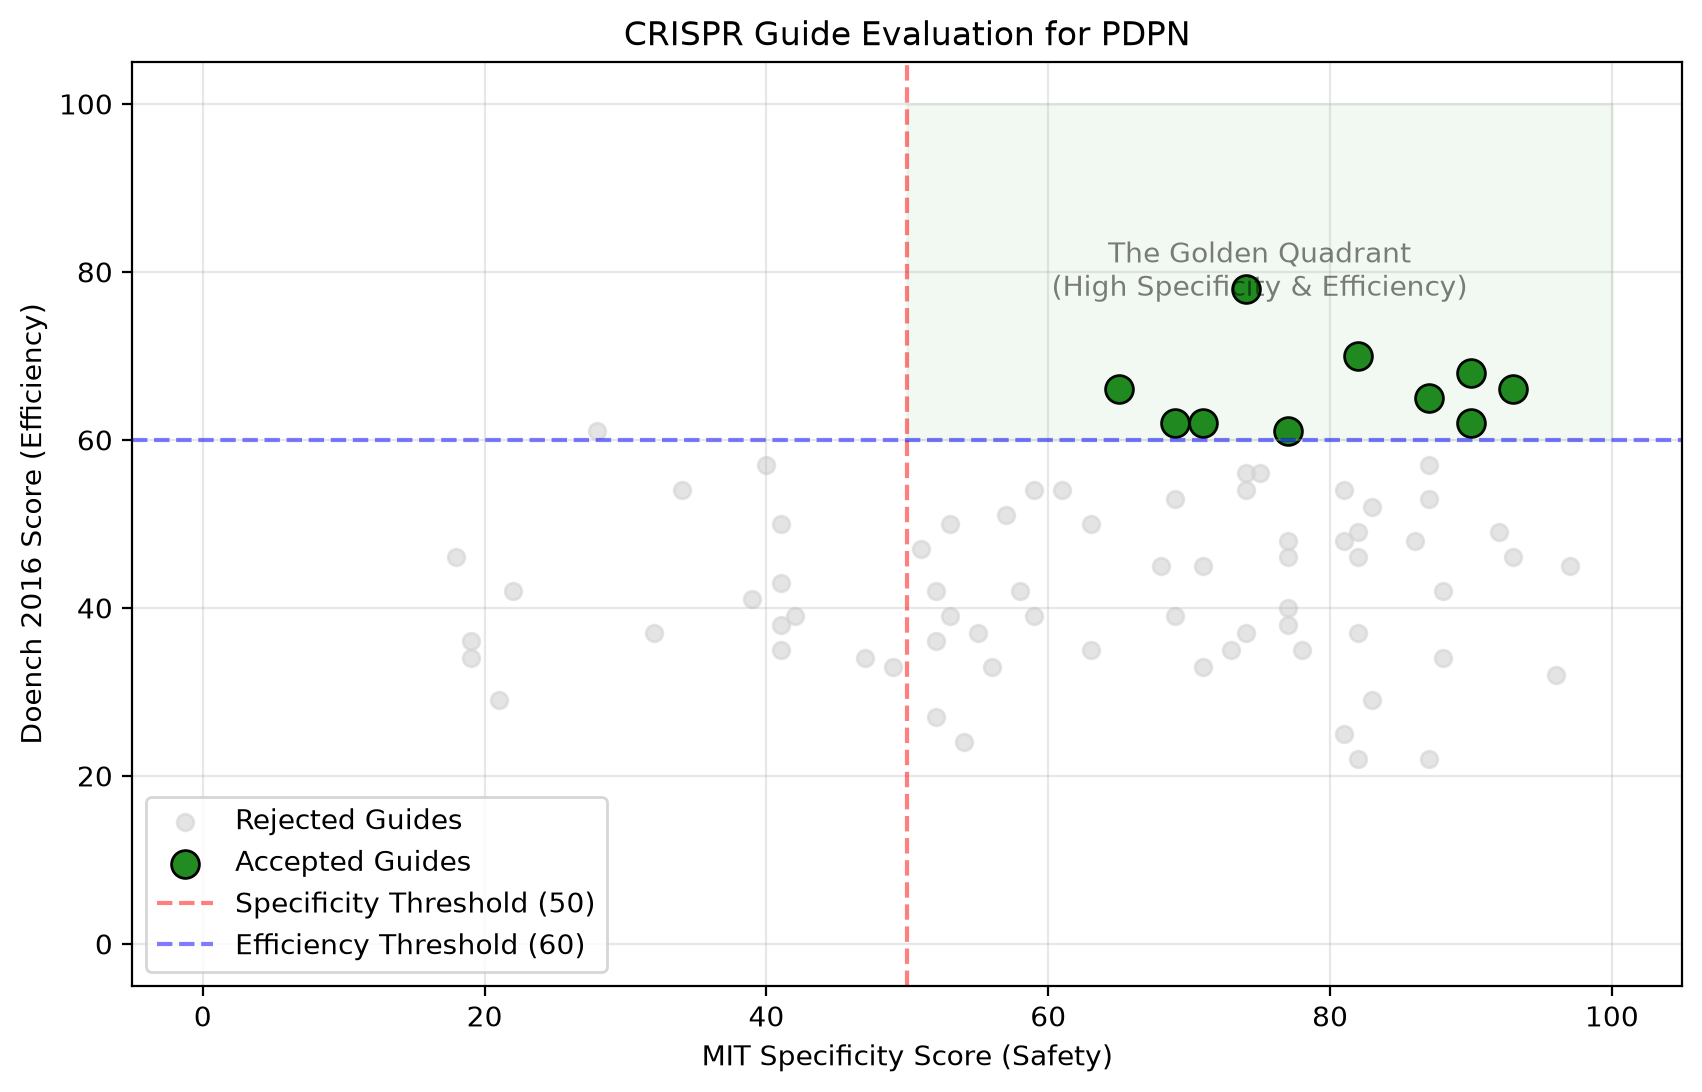


Top Guides Selected:


,#guideId,targetSeq,mitSpecScore,cfdSpecScore,Doench '16-Score
3,281forw,ACAACTCAACGGGAACGATGTGG,93,96,66
5,32rev,AGCATTTATCTCTCCCGAGGAGG,90,91,68
6,285forw,CTCAACGGGAACGATGTGGAAGG,90,95,62
9,35rev,GTCAGCATTTATCTCTCCCGAGG,87,93,65
17,59rev,GCAGTTGAGAACTTTCCGAGCGG,82,88,70


Saved PDPN candidates to '../results/tables/task2_grna_candidates.csv'


In [4]:
## Evaluation
final_candidate_gene = None

for gene in target_genes:
    print(f"--- Evaluating Candidate: {gene} ---")
    
    # Look for the CRISPOR results file for this specific gene
    crispor_files = glob.glob(f'../data/crispor_{gene.lower()}_results.xls*')
    
    if not crispor_files:
        print(f"x Failed: No CRISPOR results file found for {gene}.")
        print(" (This likely means the sequence was too short and lacked a PAM motif.)")
        continue
        
    crispor_file = crispor_files[0]
    
    # Load CRISPOR Excel file (Header is usually on row 9 / index 8)
    guides_df = pd.read_excel(crispor_file, header=8) 
    if '#guideId' not in guides_df.columns and '#seqId' not in guides_df.columns:
        temp_df = pd.read_excel(crispor_file, header=None)
        for i, row in temp_df.iterrows():
            if str(row[0]).startswith('#guideId') or str(row[0]).startswith('#seqId'):
                guides_df = pd.read_excel(crispor_file, header=i)
                break
                
    col_map = {'#seqId': '#guideId', 'MIT Spec. Score': 'mitSpecScore', 'CFD Spec. Score': 'cfdSpecScore'}
    guides_df = guides_df.rename(columns=col_map)
    
    # Apply Filters
    if "Doench '16-Score" in guides_df.columns:
        eff_mask = guides_df["Doench '16-Score"] >= 60
    else:
        eff_mask = guides_df.iloc[:, 6] >= 60 # fallback
        
    mit_mask = guides_df['mitSpecScore'] > 50
    cfd_mask = guides_df['cfdSpecScore'] > 50
    
    try:
        mm_mask = (guides_df['0-mismatches'] == 1) & (guides_df['1-mismatches'] == 0)
    except KeyError:
        mm_mask = True
        
    filtered_guides = guides_df[eff_mask & mit_mask & cfd_mask & mm_mask].copy()
    
    if len(filtered_guides) == 0:
        print(f"x Failed: 0 guides passed the strict specificity filters for {gene}.")
        print(" (This likely means the exon sequence is highly repetitive, yielding massive off-targets.)")
        continue
        
    # If we made it here, we have a successful candidate!
    print(f"o Success! {gene} yielded {len(filtered_guides)} high-quality guides passing all strict filters.")
    final_candidate_gene = gene
    
    # Scatter Plot of Efficiency vs Specificity
    plt.figure(figsize=(10, 6))
    
    # Plot all guides in grey
    doench_col = "Doench '16-Score" if "Doench '16-Score" in guides_df.columns else guides_df.columns[6]
    plt.scatter(guides_df['mitSpecScore'], guides_df[doench_col], color='lightgrey', alpha=0.6, label='Rejected Guides')
    
    # Plot accepted guides in green
    plt.scatter(filtered_guides['mitSpecScore'], filtered_guides[doench_col], color='forestgreen', s=100, edgecolor='black', label='Accepted Guides')
    
    # Draw threshold lines
    plt.axvline(50, color='red', linestyle='--', alpha=0.5, label='Specificity Threshold (50)')
    plt.axhline(60, color='blue', linestyle='--', alpha=0.5, label='Efficiency Threshold (60)')
    
    # Highlight the "Golden Quadrant"
    plt.fill_between([50, 100], 60, 100, color='green', alpha=0.05)
    plt.text(75, 80, 'The Golden Quadrant\n(High Specificity & Efficiency)', ha='center', va='center', alpha=0.5)
    
    plt.xlim(-5, 105)
    plt.ylim(-5, 105)
    plt.xlabel('MIT Specificity Score (Safety)')
    plt.ylabel('Doench 2016 Score (Efficiency)')
    plt.title(f'CRISPR Guide Evaluation for {gene}')
    plt.legend(loc='lower left')
    plt.grid(alpha=0.3)
    plt.show()
    
    top_candidates = filtered_guides.sort_values(by='mitSpecScore', ascending=False).head(5)
    cols_to_show = [c for c in ['#guideId', 'targetSeq', 'pamId', 'mitSpecScore', 'cfdSpecScore', doench_col] if c in top_candidates.columns]
    
    print("\nTop Guides Selected:")
    display(top_candidates[cols_to_show])
    
    # Save the successful guides
    top_candidates[cols_to_show].to_csv('../results/tables/task2_grna_candidates.csv', index=False)
    print(f"Saved {gene} candidates to '../results/tables/task2_grna_candidates.csv'")
    break # Stop the loop, we found our gene!

if not final_candidate_gene:
    print("\nCRITICAL FAILURE: All top 3 candidates failed biological evaluation.")